In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import glob
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader


In [2]:
def newton_B(A00,A01,A11,t, tol = 1e-5):
    B01 = np.zeros_like(A00)
    def funcs(x):
        x2 = x*x
        
        sqrtA00 = np.sqrt(A00 - x2)
        sqrtA11 = np.sqrt(A11 - x2)
        if ((A00 - x2) <0).any():
            warnings.warn(f'A00 - t = {t}')
        if ((A11 - x2) <0).any():
            warnings.warn(f'A11 - t = {t}')
        f  = -A01 + x*(sqrtA00 + sqrtA11)
        df = sqrtA00 + sqrtA11 - (x2/sqrtA00 + x2/sqrtA11)
        return f, df, sqrtA00, sqrtA11

    f, df, B00, B11 = funcs(B01)
    i = 0
    while np.linalg.norm(f) > tol and i < 500:
        B01 = B01 - f/df
        f, df, B00, B11 = funcs(B01)
        i+=1
        if(np.isnan(B01).any()):
            print("The Array contain NaN values")
            break
    return B00, B01, B11

In [3]:
def calc_energy(A, Re, Wi, beta, L2):
    traA = A[..., 0] + A[..., 2]
    energy = (1-beta)/(Re*Wi) * (L2 * traA / (L2 - traA))
    return energy.sum(axis=(0,1))

In [4]:
dir_path = '../../npz_data/toy'
filename = '128x128_Wi-5_L2_20.0_PTT-0_VelType-stsxsy_Periodic-True_LogConf.npz'

fields = np.load(f'{dir_path}/{filename}', allow_pickle=True)
A = fields['A']

In [5]:
Bs = newton_B(A[...,0],A[...,1],A[...,2],t=0)

In [6]:
B = np.stack(Bs, axis=-1)
B.shape

(128, 128, 10001, 3)

In [7]:
Wi = 5
L2 = 20
Re = 1
beta = 0.5
elastic_energy = calc_energy(A, Re, Wi, beta, L2)

In [27]:
elastic_energy_wrong = calc_energy(A, Re, Wi, beta, L2)

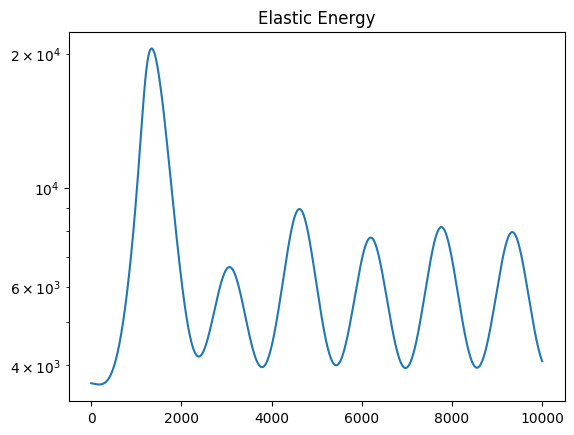

In [9]:
plt.plot(elastic_energy)
plt.title('Elastic Energy')
plt.yscale('log')

In [ ]:
dt = 0.001


# Second-order central difference: dA/dt ≈ (A[i+1] - A[i-1]) / (2*dt)
dA_dt = np.zeros_like(A)
dA_dt[:, :, 1:-1, :] = (A[:, :, 2:, :] - A[:, :, :-2, :]) / (2 * dt)

# For boundaries, use second-order forward/backward difference
dA_dt[:, :, 0, :] = (-3*A[:, :, 0, :] + 4*A[:, :, 1, :] - A[:, :, 2, :]) / (2 * dt)
dA_dt[:, :, -1, :] = (A[:, :, -3, :] - 4*A[:, :, -2, :] + 3*A[:, :, -1, :]) / (2 * dt)

print(f"dA/dt shape: {dA_dt.shape}")

dA/dt shape: (128, 128, 10001, 3)


### Exact dA/dt from the PDE

`∂A/∂t = -(v·∇)A + (∇v)A + A(∇v)ᵀ - (1/Wi) g(A-I)`, with:
- `u = sin(t) sin(x) cos(y)`, `v = -sin(t) sin(y) cos(x)` (the `stsxsy` flow — divergence-free, matches the domain `[0, 2π)²`) and `∇v` from their closed-form partials.
- `g(A-I) = f·A - I`, `f = L2/(L2 - tr(A))` (FENE-P closure).

`g(A-I)` is pointwise in the already-known `A(t)` (exact, no differencing), and `∇v` is exact since `v` is analytic. Only the advection term `(v·∇)A` needs a spatial derivative of the sampled field `A`, computed here via FFT (spectral differentiation — exact to machine precision for a periodic band-limited-ish field, unlike the finite difference in time used below).

**Axis assumption**: axis 0 of `A` ↔ `x`, axis 1 ↔ `y`. The flow is not `x↔y`-symmetric, so the comparison plot below should reveal if this is backwards.

In [ ]:
def spectral_deriv(field, axis, dx):
    """d(field)/d(axis) via FFT differentiation, assuming periodicity along `axis`."""
    N = field.shape[axis]
    k = 2 * np.pi * np.fft.fftfreq(N, d=dx)
    shape = [1] * field.ndim
    shape[axis] = N
    k = k.reshape(shape)
    F = np.fft.fft(field, axis=axis)
    return np.fft.ifft(1j * k * F, axis=axis).real


N = A.shape[0]
dx = 2 * np.pi / N
x_vals = np.arange(N) * dx
X, Y = np.meshgrid(x_vals, x_vals, indexing='ij')   # X varies along axis 0, Y along axis 1
Xg = X[:, :, None]
Yg = Y[:, :, None]

t_axis_full = dt * np.arange(A.shape[2])
Tg = t_axis_full[None, None, :]

u  =  np.sin(Tg) * np.sin(Xg) * np.cos(Yg)
vv = -np.sin(Tg) * np.sin(Yg) * np.cos(Xg)

Lxx =  np.sin(Tg) * np.cos(Xg) * np.cos(Yg)   # du/dx
Lxy = -np.sin(Tg) * np.sin(Xg) * np.sin(Yg)   # du/dy
Lyx =  np.sin(Tg) * np.sin(Xg) * np.sin(Yg)   # dv/dx
Lyy = -np.sin(Tg) * np.cos(Xg) * np.cos(Yg)   # dv/dy

dAdx = spectral_deriv(A, axis=0, dx=dx)
dAdy = spectral_deriv(A, axis=1, dx=dx)
adv = u[..., None] * dAdx + vv[..., None] * dAdy

A00, A01, A11 = A[..., 0], A[..., 1], A[..., 2]

# L A + (L A)^T, with L = [[Lxx, Lxy], [Lyx, Lyy]]
M00 = 2 * (Lxx * A00 + Lxy * A01)
M11 = 2 * (Lyx * A01 + Lyy * A11)
M01 = Lyx * A00 + (Lxx + Lyy) * A01 + Lxy * A11

trA = A00 + A11
fPTT = L2 / (L2 - trA)

dA00_dt = -adv[..., 0] + M00 - (1 / Wi) * (fPTT * A00 - 1.0)
dA01_dt = -adv[..., 1] + M01 - (1 / Wi) * (fPTT * A01)
dA11_dt = -adv[..., 2] + M11 - (1 / Wi) * (fPTT * A11 - 1.0)

dA_dt_exact = np.stack([dA00_dt, dA01_dt, dA11_dt], axis=-1)
print(f"dA/dt (exact) shape: {dA_dt_exact.shape}")

In [ ]:
# Sanity check: exact (PDE) vs finite-difference dA/dt, both globally and at one grid point.
# drop the FD boundary snapshots (t=0, t=-1), where the one-sided stencil is least accurate
flat_exact_interior = dA_dt_exact[:, :, 1:-1, :].reshape(-1, 3)
flat_fd_interior = dA_dt[:, :, 1:-1, :].reshape(-1, 3)
rel_err = np.linalg.norm(flat_exact_interior - flat_fd_interior, axis=0) / np.linalg.norm(flat_fd_interior, axis=0)
print("Relative L2 diff (exact vs FD), per component (A00, A01, A11):", rel_err)

i, j = N // 2, N // 2
fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
labels = ["A00", "A01", "A11"]
for c in range(3):
    axes[c].plot(t_axis_full, dA_dt[i, j, :, c], label="finite difference")
    axes[c].plot(t_axis_full, dA_dt_exact[i, j, :, c], "--", label="exact (PDE)")
    axes[c].set_ylabel(f"d{labels[c]}/dt")
axes[0].legend()
axes[-1].set_xlabel("t")
fig.suptitle(f"dA/dt at grid point (i={i}, j={j}): exact vs. finite difference")
fig.tight_layout()
plt.show()

In [10]:
dt = 0.001

# Second-order central difference: dA/dt ≈ (A[i+1] - A[i-1]) / (2*dt)
dB_dt = np.zeros_like(B)
dB_dt[:, :, 1:-1, :] = (B[:, :, 2:, :] - B[:, :, :-2, :]) / (2 * dt)

# For boundaries, use second-order forward/backward difference
dB_dt[:, :, 0, :] = (-3*B[:, :, 0, :] + 4*B[:, :, 1, :] - B[:, :, 2, :]) / (2 * dt)
dB_dt[:, :, -1, :] = (B[:, :, -3, :] - 4*B[:, :, -2, :] + 3*B[:, :, -1, :]) / (2 * dt)

print(f"dA/dt shape: {dB_dt.shape}")

dA/dt shape: (128, 128, 10001, 3)


In [12]:
out_dir = 'C:/Users/fabio/Desktop/npz_data/snapshots_dataset'
full_dir = os.path.join(out_dir, 'full_train')
os.makedirs(full_dir, exist_ok=True)
n_snaps = B.shape[2]
B_snapshots = [torch.from_numpy(B[:, :, i, :]).permute(2,0,1).float() for i in range(n_snaps)]
dB_dt_snapshots = [torch.from_numpy(dB_dt[:, :, i, :]).permute(2,0,1).float() for i in range(n_snaps)]
test_count = 1000
full_train_indices = np.arange(0, n_snaps - test_count)
# save files (indexing per-split starting at 0)
for j, i in enumerate(full_train_indices):
    torch.save(B_snapshots[i], os.path.join(full_dir, f'B_{j:05d}.pt'))
    torch.save(dB_dt_snapshots[i], os.path.join(full_dir, f'dB_dt_{j:05d}.pt'))

In [ ]:

# Create dataset from B array and dB_dt
# B has shape (128, 128, 10001, 3), dB_dt has shape (128, 128, 10001, 3)
n_snaps = B.shape[2]
B_snapshots = [torch.from_numpy(B[:, :, i, :]).permute(2,0,1).float() for i in range(n_snaps)]
dB_dt_snapshots = [torch.from_numpy(dB_dt[:, :, i, :]).permute(2,0,1).float() for i in range(n_snaps)]

out_dir = 'C:/Users/fabio/Desktop/npz_data/snapshots_dataset'
train_dir = os.path.join(out_dir, 'train')
val_dir = os.path.join(out_dir, 'val')
test_dir = os.path.join(out_dir, 'test')
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

test_count = 1000
val_count = 1000

# last `test_count` samples -> test
test_start = n_snaps - test_count
test_indices = np.arange(test_start, n_snaps)

# from the first 9000 (or as many as available before the test block) choose val_count for validation
pool_end = min(9000, n_snaps - test_count)
pool_indices = np.arange(0, pool_end)

rng = np.random.default_rng(42)
if len(pool_indices) < val_count:
    raise ValueError("Not enough samples in the pool to select the requested validation set.")
val_indices = rng.choice(pool_indices, size=val_count, replace=False)

# remaining indices before test -> training
train_indices = np.setdiff1d(np.arange(0, n_snaps - test_count), val_indices)

# save files (indexing per-split starting at 0)
for j, i in enumerate(train_indices):
    torch.save(B_snapshots[i], os.path.join(train_dir, f'B_{j:05d}.pt'))
    torch.save(dB_dt_snapshots[i], os.path.join(train_dir, f'dB_dt_{j:05d}.pt'))

for j, i in enumerate(val_indices):
    torch.save(B_snapshots[i], os.path.join(val_dir, f'B_{j:05d}.pt'))
    torch.save(dB_dt_snapshots[i], os.path.join(val_dir, f'dB_dt_{j:05d}.pt'))

for j, i in enumerate(test_indices):
    torch.save(B_snapshots[i], os.path.join(test_dir, f'B_{j:05d}.pt'))
    torch.save(dB_dt_snapshots[i], os.path.join(test_dir, f'dB_dt_{j:05d}.pt'))

print(f"Total snaps: {n_snaps}")
print(f"Train: {len(train_indices)}  Val: {len(val_indices)}  Test: {len(test_indices)}")
print(f"Single B tensor shape: {B_snapshots[0].shape}")
print(f"Single dB_dt tensor shape: {dB_dt_snapshots[0].shape}")


Total snaps: 10001
Train: 8001  Val: 1000  Test: 1000
Single B tensor shape: torch.Size([3, 128, 128])
Single dB_dt tensor shape: torch.Size([3, 128, 128])


In [23]:
from torch.utils.data import Dataset, DataLoader

# training cell for SINDy autoencoder
import importlib.util, sys, torch, glob, os

# load module from file (adjust path if needed)
spec = importlib.util.spec_from_file_location("sindy_ae_module",
    "c:/Users/fabio/OneDrive/Área de Trabalho/Aulas/Projeto Doutorado/Autoencoder/reduction_methods/src/Autoencoder/SINDy_Autoencoder.py")
sindy_mod = importlib.util.module_from_spec(spec)
sys.modules["sindy_ae_module"] = sindy_mod
spec.loader.exec_module(sindy_mod)
SINDyAutoencoderModule = sindy_mod.SINDyAutoencoderModule
loss_sindy_ae = sindy_mod.loss_sindy_ae

# dataset that loads saved .pt snapshots
class SnapshotDataset(Dataset):
    def __init__(self, folder):
        self.folder = folder
        self.files = sorted(glob.glob(os.path.join(folder, "B_*.pt")))
    def __len__(self):
        return len(self.files)
    def __getitem__(self, i):
        A = torch.load(self.files[i]).float()        # shape (H,W,C)
        dA = torch.load(os.path.join(self.folder, f"dB_dt_{i:05d}.pt")).float()
        return A, dA

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# use existing train_dir and val_dir from notebook
batch_size = 512
train_ds = SnapshotDataset(train_dir)
test_ds = SnapshotDataset(test_dir)
val_ds = SnapshotDataset(val_dir)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)

# model hyperparams (tweak as needed)
channels, H, W = 3, 128, 128
n_filters = 16
n_layers = 3
latent_dim = 10
degree = 2
include_bias = False

# infer input shape from the datasets and build model accordingly
if len(train_ds) > 0:
    sample_A, _ = train_ds[0]
elif len(val_ds) > 0:
    sample_A, _ = val_ds[0]
elif len(test_loader) > 0:
    sample_A, _ = test_ds[0]
else:
    raise RuntimeError("No samples found in train/val/test datasets to infer input shape.")

channels, H, W = sample_A.shape

In [26]:
A = torch.load("C:/Users/fabio/Desktop/npz_data/B_00000.pt").float()
A.shape

torch.Size([3, 128, 128])

In [25]:
channels, H, W, sample_A.shape

(3, 128, 128, torch.Size([3, 128, 128]))

In [ ]:
python -c "
import torch, glob, os
folder = '/node/fabio/npz_data/snapshots_dataset/train'
f = sorted(glob.glob(os.path.join(folder, \"B_*.pt\")))[0]
t = torch.load(f)
print(f)
print(\"shape:\", t.shape, \"dtype:\", t.dtype)
"

In [11]:
from torch.utils.data import Dataset, DataLoader

# training cell for SINDy autoencoder
import importlib.util, sys, torch, glob, os

# load module from file (adjust path if needed)
spec = importlib.util.spec_from_file_location("sindy_ae_module",
    "c:/Users/fabio/OneDrive/Área de Trabalho/Aulas/Projeto Doutorado/Autoencoder/reduction_methods/src/Autoencoder/SINDy_Autoencoder.py")
sindy_mod = importlib.util.module_from_spec(spec)
sys.modules["sindy_ae_module"] = sindy_mod
spec.loader.exec_module(sindy_mod)
SINDyAutoencoderModule = sindy_mod.SINDyAutoencoderModule
loss_sindy_ae = sindy_mod.loss_sindy_ae

# dataset that loads saved .pt snapshots
class SnapshotDataset(Dataset):
    def __init__(self, folder):
        self.folder = folder
        self.files = sorted(glob.glob(os.path.join(folder, "A_*.pt")))
    def __len__(self):
        return len(self.files)
    def __getitem__(self, i):
        A = torch.load(self.files[i]).float()        # shape (H,W,C)
        dA = torch.load(os.path.join(self.folder, f"dA_dt_{i:05d}.pt")).float()
        # conv net expects (C,H,W)
        A = A.permute(2,0,1)
        dA = dA.permute(2,0,1)
        return A, dA

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# use existing train_dir and val_dir from notebook
batch_size = 512
train_ds = SnapshotDataset(train_dir)
test_ds = SnapshotDataset(test_dir)
val_ds = SnapshotDataset(val_dir)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)

# model hyperparams (tweak as needed)
channels, H, W = 3, 128, 128
n_filters = 16
n_layers = 3
latent_dim = 10
degree = 2
include_bias = False

# infer input shape from the datasets and build model accordingly
if len(train_ds) > 0:
    sample_A, _ = train_ds[0]
elif len(val_ds) > 0:
    sample_A, _ = val_ds[0]
elif len(test_loader) > 0:
    sample_A, _ = test_ds[0]
else:
    raise RuntimeError("No samples found in train/val/test datasets to infer input shape.")

channels, H, W = sample_A.shape
model = SINDyAutoencoderModule(n_filters, n_layers, latent_dim, (channels, H, W), degree, include_bias).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-6)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

epochs = 20

for epoch in range(1, epochs+1):
    model.train()
    running = 0.0
    for A_batch, dA_batch in train_loader:
        A_batch = A_batch.to(device)
        dA_batch = dA_batch.to(device)
        A_batch.requires_grad_(True)   # required for jvp inside loss
        loss = loss_sindy_ae(A_batch, model, dA_batch, lambda1=1.0, lambda2=1.0, lambda3=1e-4)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running += loss.item() * A_batch.size(0)
    scheduler.step()

    # quick validation loss
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for A_batch, dA_batch in val_loader:
            A_batch = A_batch.to(device)
            dA_batch = dA_batch.to(device)
            A_batch.requires_grad_(True)
            val_loss += loss_sindy_ae(A_batch, model, dA_batch, lambda1=1.0, lambda2=1.0, lambda3=1e-4).item() * A_batch.size(0)

    print(f"Epoch {epoch}/{epochs}  train_loss={running/len(train_ds):.6f}  val_loss={val_loss/len(val_ds):.6f}")

# save model
os.makedirs("models", exist_ok=True)
torch.save(model.state_dict(), "models/sindy_ae_final.pth")

c:\Users\fabio\anaconda3\envs\reduction_env\Lib\site-packages\torch\autograd\graph.py:841: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:270.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 1/20  train_loss=15901.351274  val_loss=12.277653
Epoch 2/20  train_loss=10.987992  val_loss=10.189318
Epoch 3/20  train_loss=9.094232  val_loss=8.405314
Epoch 4/20  train_loss=8.358392  val_loss=7.924216
Epoch 5/20  train_loss=7.976436  val_loss=7.690541
Epoch 6/20  train_loss=7.491487  val_loss=7.220930
Epoch 7/20  train_loss=7.227675  val_loss=12.268887
Epoch 8/20  train_loss=7.142615  val_loss=6.137090
Epoch 9/20  train_loss=6.084454  val_loss=11.238032
Epoch 10/20  train_loss=5.644253  val_loss=9.275899
Epoch 11/20  train_loss=4.471434  val_loss=5.919220
Epoch 12/20  train_loss=4.255187  val_loss=4.068555
Epoch 13/20  train_loss=4.754873  val_loss=10.902234
Epoch 14/20  train_loss=2402.883202  val_loss=36.681569
Epoch 15/20  train_loss=21.528378  val_loss=17.676159
Epoch 16/20  train_loss=13.664812  val_loss=12.385575
Epoch 17/20  train_loss=11.103596  val_loss=10.089077
Epoch 18/20  train_loss=9.149519  val_loss=7.870592
Epoch 19/20  train_loss=7.482971  val_loss=7.565110
E

In [ ]:
import optuna
from optuna import TrialPruned
from torch.utils.data import DataLoader

# re-use SnapshotDataset, SINDyAutoencoderModule, loss_sindy_ae, train_dir, val_dir, device, degree, include_bias, epochs
channels, H, W = sample_A.shape

def objective(trial):
    n_filters = trial.suggest_int("n_filters", 8, 64, step=8)
    n_layers = trial.suggest_int("n_layers", 1, 4)
    latent_dim = trial.suggest_int("latent_dim", 2, 4, log=False)
    lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)
    weight_decay = trial.suggest_loguniform("weight_decay", 1e-7, 1e-4)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256, 512])
    lambda1 = trial.suggest_loguniform("lambda1", 1e-3, 10.0)
    lambda2 = trial.suggest_loguniform("lambda2", 1e-3, 10.0)
    lambda3 = trial.suggest_loguniform("lambda3", 1e-6, 1e-2)

    model = SINDyAutoencoderModule(n_filters, n_layers, latent_dim, (channels, H, W), degree, include_bias).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_ds = SnapshotDataset(train_dir)
    val_ds = SnapshotDataset(val_dir)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)

    n_epochs = min(5, epochs)  # short runs for tuning
    for ep in range(1, n_epochs + 1):
        model.train()
        for A_batch, dA_batch in train_loader:
            A_batch = A_batch.to(device); dA_batch = dA_batch.to(device)
            A_batch.requires_grad_(True)
            loss = loss_sindy_ae(A_batch, model, dA_batch, lambda1=lambda1, lambda2=lambda2, lambda3=lambda3)
            optimizer.zero_grad(); loss.backward(); optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for A_batch, dA_batch in val_loader:
                A_batch = A_batch.to(device); dA_batch = dA_batch.to(device)
                A_batch.requires_grad_(True)
                val_loss += loss_sindy_ae(A_batch, model, dA_batch, lambda1=lambda1, lambda2=lambda2, lambda3=lambda3).item() * A_batch.size(0)
        val_loss = val_loss / len(val_ds)

        trial.report(val_loss, ep)
        if trial.should_prune():
            raise TrialPruned()

    return val_loss

study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42),
                            pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1))
study.optimize(objective, n_trials=50, n_jobs=1)

print("Best value:", study.best_value)
print("Best params:", study.best_params)

# save study results
study.trials_dataframe().to_csv("optuna_sindy_ae_trials.csv", index=False)

In [8]:

# dataset that loads saved .pt snapshots
class SnapshotDataset(Dataset):
    def __init__(self, folder):
        self.folder = folder
        self.files = sorted(glob.glob(os.path.join(folder, "B_*.pt")))
    def __len__(self):
        return len(self.files)
    def __getitem__(self, i):
        A = torch.load(self.files[i]).float()        # shape (H,W,C)
        dA = torch.load(os.path.join(self.folder, f"dB_dt_{i:05d}.pt")).float()
        return A, dA

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# use existing train_dir and val_dir from notebook
out_dir = 'C:/Users/fabio/Desktop/npz_data/snapshots_dataset'
train_dir = os.path.join(out_dir, 'train')
val_dir = os.path.join(out_dir, 'val')
test_dir = os.path.join(out_dir, 'test')
batch_size = 512
test_ds = SnapshotDataset(test_dir)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)


In [12]:
# training cell for SINDy autoencoder
import importlib.util, sys, torch, glob, os

# load module from file (adjust path if needed)
spec = importlib.util.spec_from_file_location("sindy_ae_module",
    "c:/Users/fabio/OneDrive/Área de Trabalho/Aulas/Projeto Doutorado/Autoencoder/reduction_methods/src/Autoencoder/SINDy_Autoencoder.py")
sindy_mod = importlib.util.module_from_spec(spec)
sys.modules["sindy_ae_module"] = sindy_mod
spec.loader.exec_module(sindy_mod)
SINDyAutoencoderModule = sindy_mod.SINDyAutoencoderModule
loss_sindy_ae = sindy_mod.loss_sindy_ae

# Load the best checkpoint saved during training
models_dir = "C:/Users/fabio/OneDrive/Área de Trabalho/Aulas/Projeto Doutorado/Autoencoder/reduction_methods/ModelsTorch/SINDy_AE_Kernel_old"
checkpoint_path = models_dir + "/best_sindy_ae_checkpoint.pt"
checkpoint = torch.load(checkpoint_path, map_location=device)

# Reconstruct model with saved parameters
model_test = SINDyAutoencoderModule(
    checkpoint["best_params"]["n_filters"],
    checkpoint["best_params"]["n_layers"],
    checkpoint["latent_dim"],
    checkpoint["input_shape"],
    checkpoint["degree"],
    checkpoint["include_bias"]
).to(device)

model_test.load_state_dict(checkpoint["model_state_dict"])
model_test.eval()

# Evaluate on test set
test_loss = 0.0
rec_losses = []
sindy_losses = []

with torch.no_grad():
    for A_batch, dA_batch in test_loader:
        A_batch = A_batch.to(device)
        dA_batch = dA_batch.to(device)
        A_batch.requires_grad_(True)
        
        # Compute loss components
        loss = loss_sindy_ae(
            A_batch, model_test, dA_batch,
            weights=checkpoint["best_params"].get("weights", [1.0, 1.0, 1e-4, 1.0, 1.0]),
            rec_energy=checkpoint["rec_energy"],
            L2=checkpoint["L2"]
        )
        test_loss += loss.item() * A_batch.size(0)

test_loss /= len(test_ds)
print(f"Test Loss: {test_loss:.6f}")

# Visualize reconstructions
model_test.eval()
with torch.no_grad():
    sample_A, sample_dA = test_ds[0]
    sample_A = sample_A.unsqueeze(0).to(device)
    
    # Get model outputs
    latent = model_test.encoder(sample_A)
    A_rec = model_test.decoder(latent)
    
    print(f"Original shape: {sample_A.shape}")
    print(f"Reconstructed shape: {A_rec.shape}")
    print(f"Latent shape: {latent.shape}")
    # print(f"Predicted dA shape: {dA_pred.shape}")
    print(f"Reconstruction error (L2): {(sample_A - A_rec).norm().item():.6f}")

Test Loss: 19.200391
Original shape: torch.Size([1, 3, 128, 128])
Reconstructed shape: torch.Size([1, 3, 128, 128])
Latent shape: torch.Size([1, 3])
Reconstruction error (L2): 26.581060


-16.08793338871002